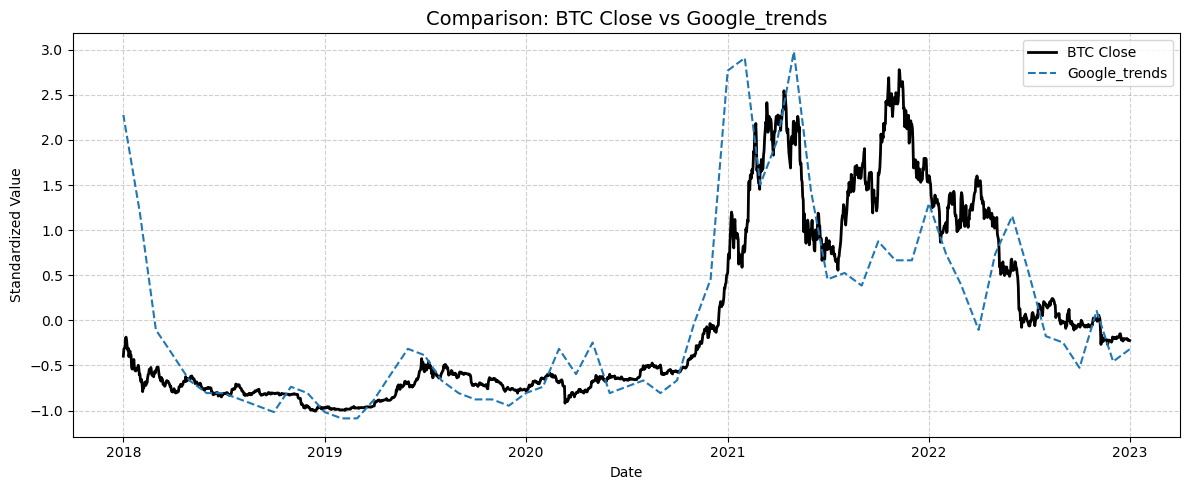

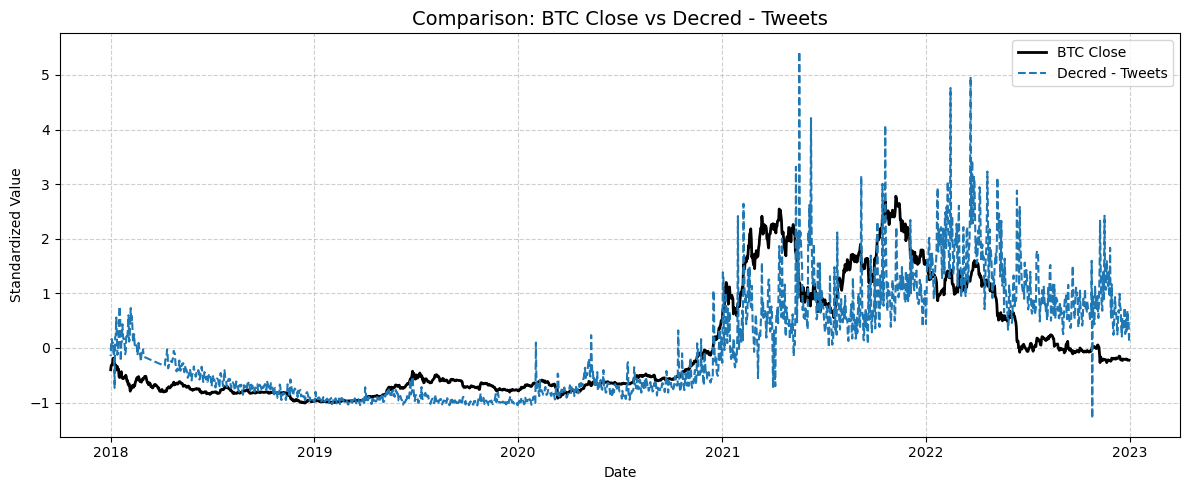

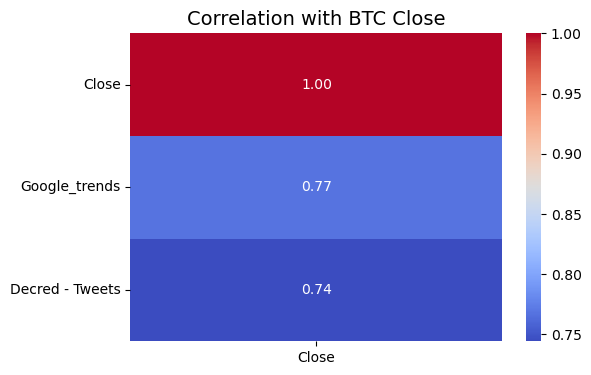


📊 Correlation Coefficients with BTC Close:
Close              1.000
Google_trends      0.767
Decred - Tweets    0.744
Name: Close, dtype: float64
Correlation and p-values with BTC Close:

Google_trends        | Correlation:  0.767 | p-value: 0.0000e+00
Decred - Tweets      | Correlation:  0.744 | p-value: 3.5573e-322


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Read the data
df = pd.read_csv("Attention.csv")

# Convert date format
df['Date'] = pd.to_datetime(df['Date'])

# Keep only the required columns
cols = ['Date', 'Close', 'Google_trends', 'Decred - Tweets']
df = df[cols].dropna()

# Standardize numerical columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Close', 'Google_trends', 'Decred - Tweets']])
scaled_df = pd.DataFrame(scaled_data, columns=['Close', 'Google_trends', 'Decred - Tweets'])
scaled_df['Date'] = df['Date']

# Line plot comparisons
for col in ['Google_trends', 'Decred - Tweets']:
    plt.figure(figsize=(12, 5))
    plt.plot(scaled_df['Date'], scaled_df['Close'], label='BTC Close', color='black', linewidth=2)
    plt.plot(scaled_df['Date'], scaled_df[col], label=col, linestyle='--')
    plt.title(f'Comparison: BTC Close vs {col}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Standardized Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 4))
corr = scaled_df[['Close', 'Google_trends', 'Decred - Tweets']].corr()
sns.heatmap(corr[['Close']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with BTC Close", fontsize=14)
plt.show()

# Print specific correlation coefficients
print("\n📊 Correlation Coefficients with BTC Close:")
print(corr['Close'].sort_values(ascending=False).round(3))

from scipy.stats import pearsonr

# Set predictor variable list
predictors = ['Google_trends', 'Decred - Tweets']

print("Correlation and p-values with BTC Close:\n")
for col in predictors:
    corr, pval = pearsonr(df['Close'], df[col])
    print(f"{col:20s} | Correlation: {corr:>6.3f} | p-value: {pval:.4e}")


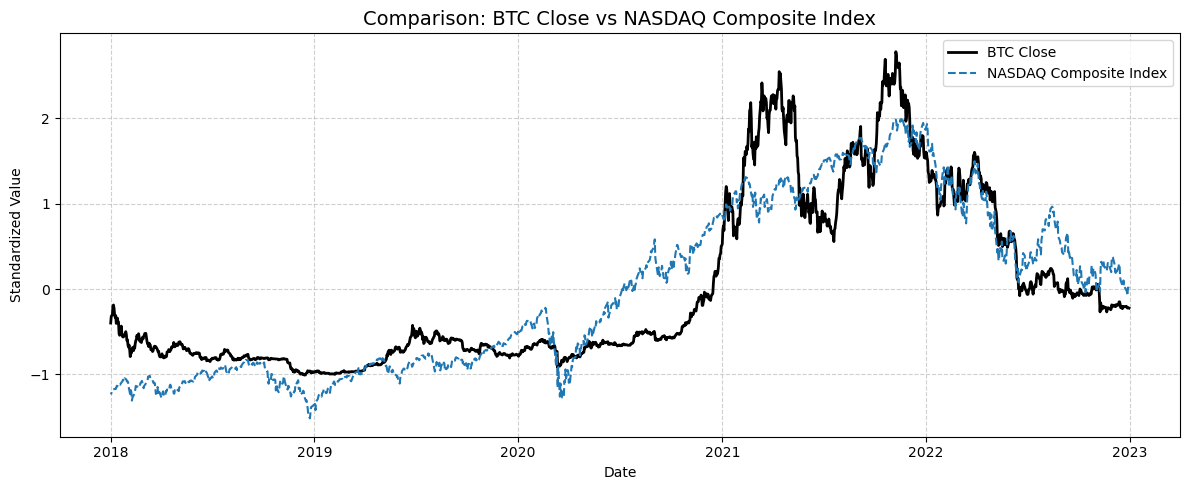

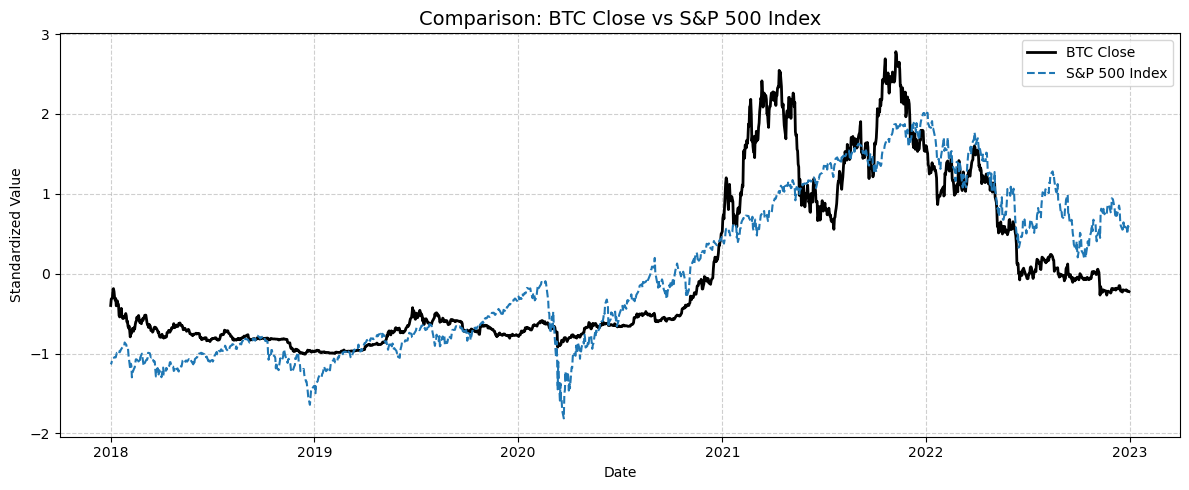

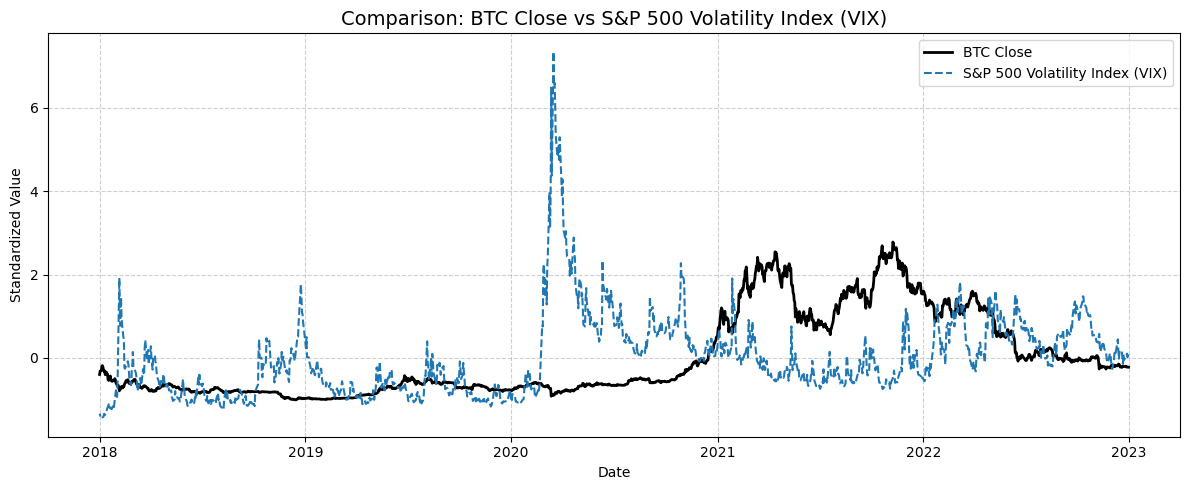

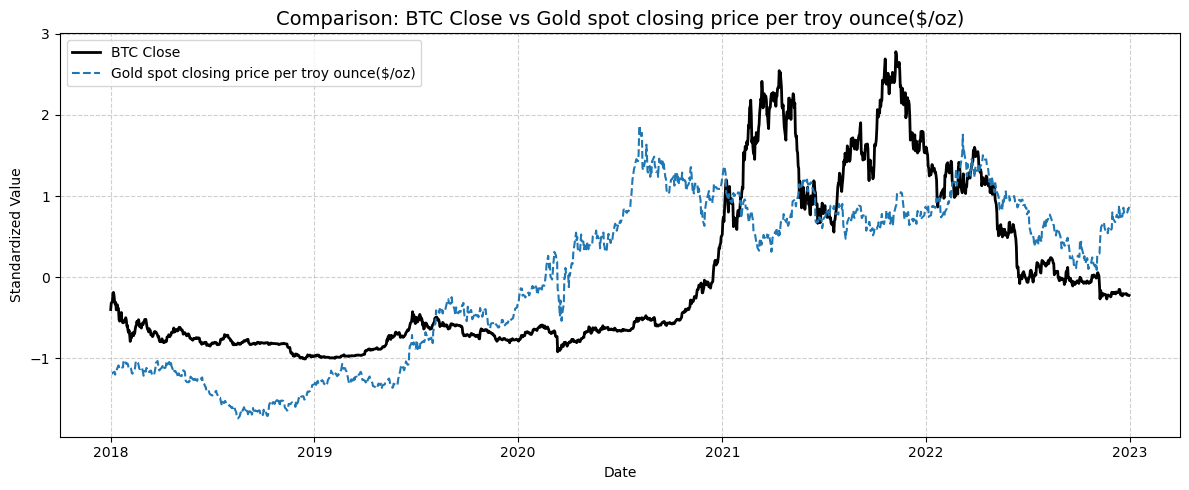

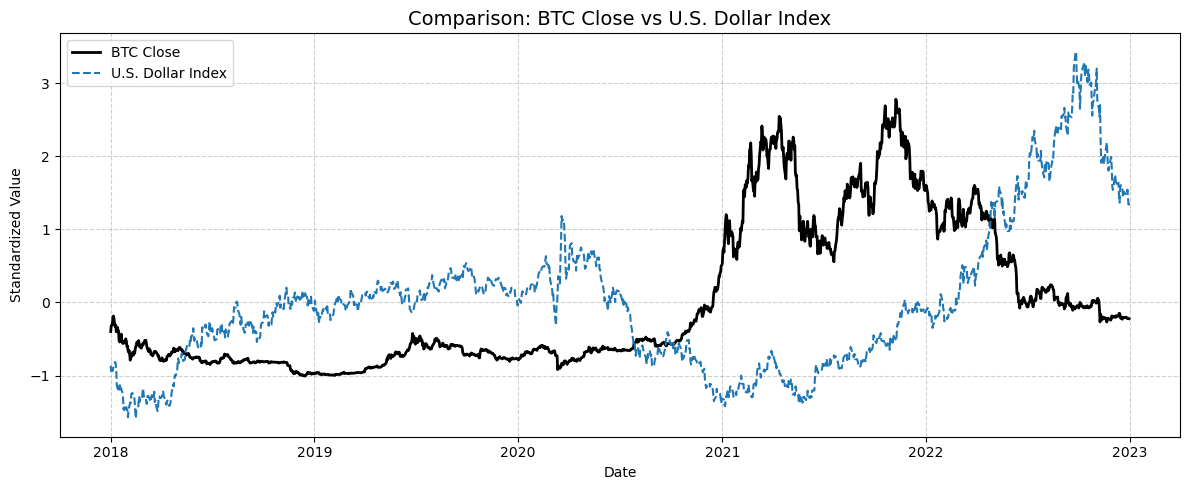

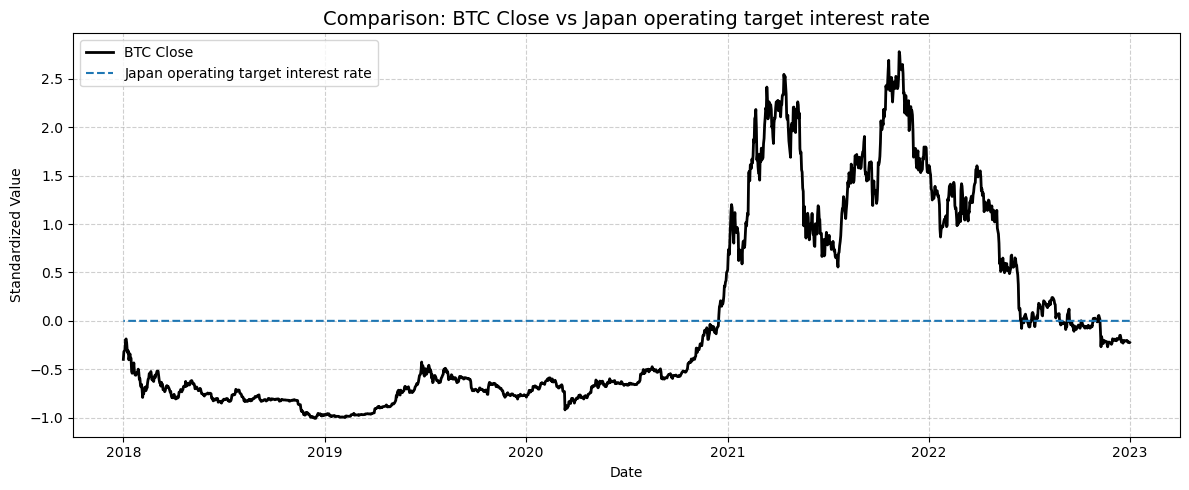

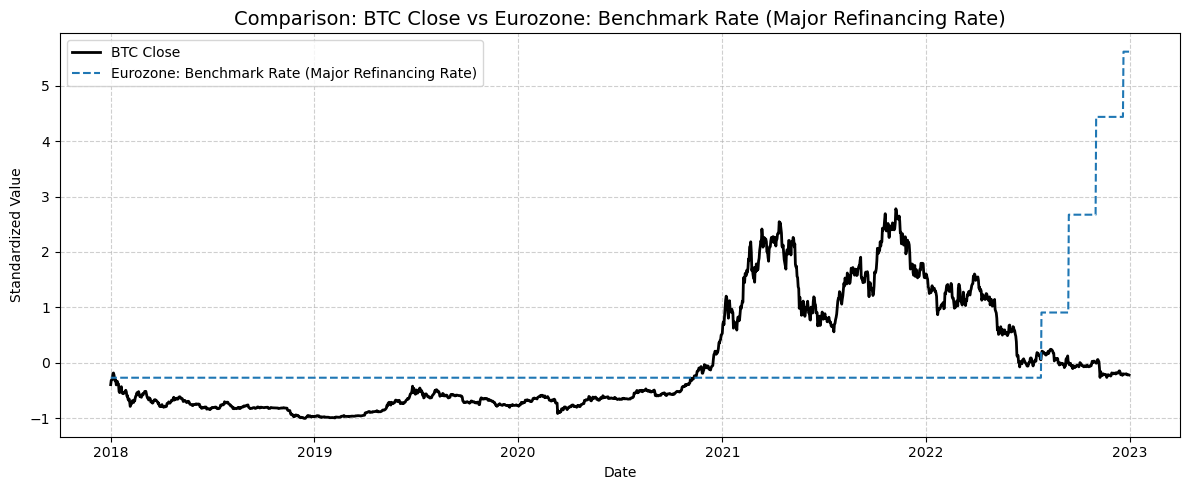

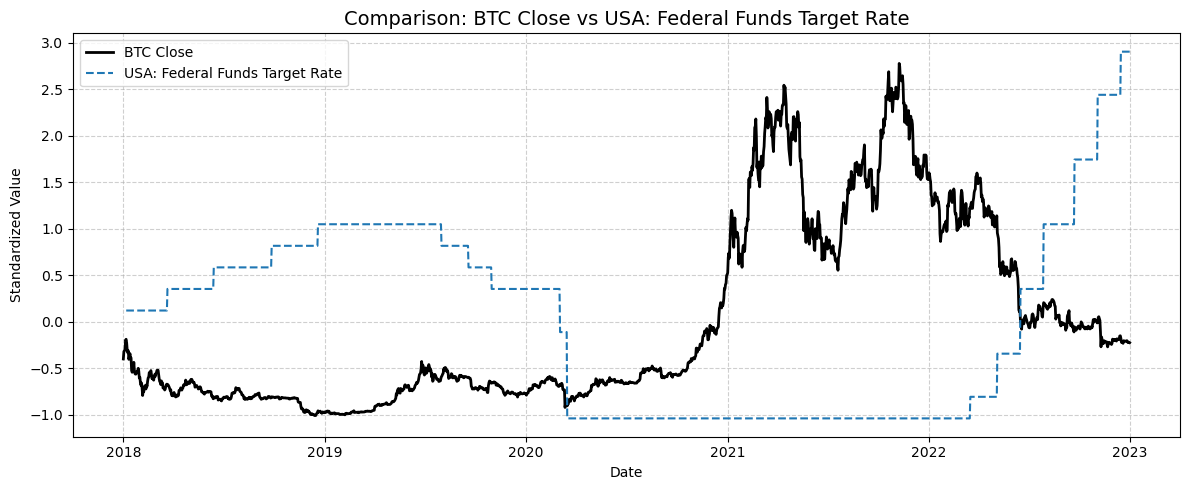

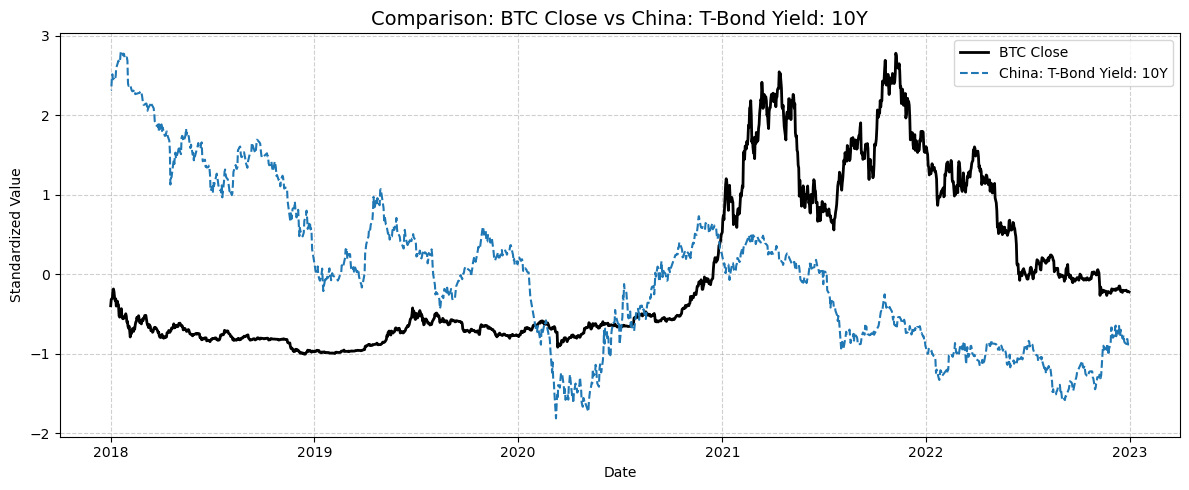

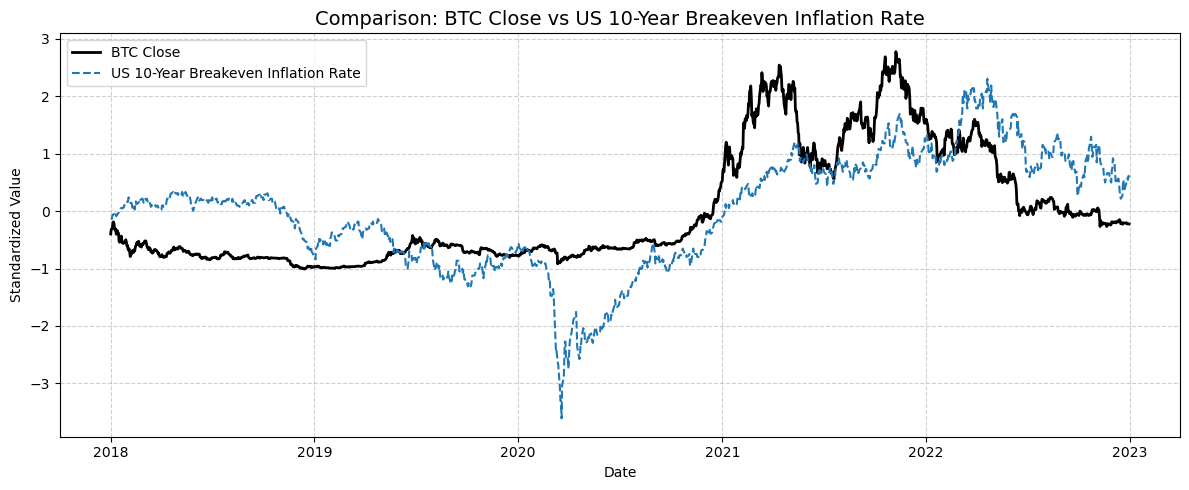

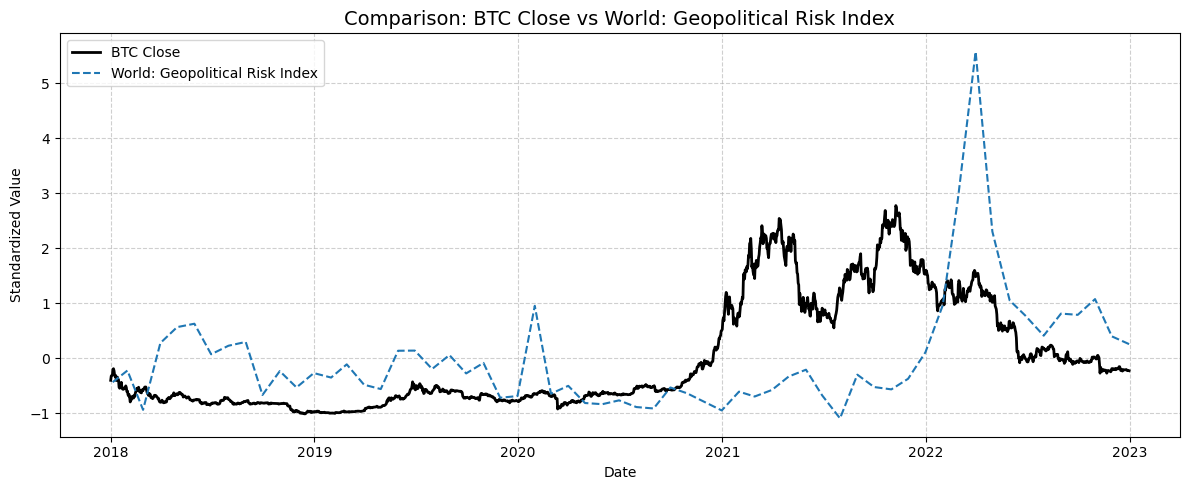

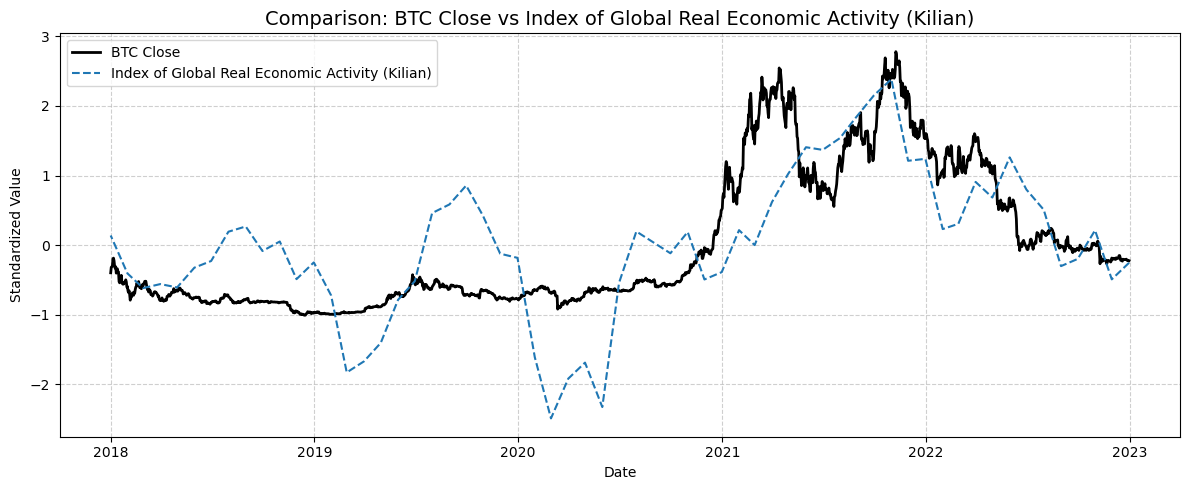

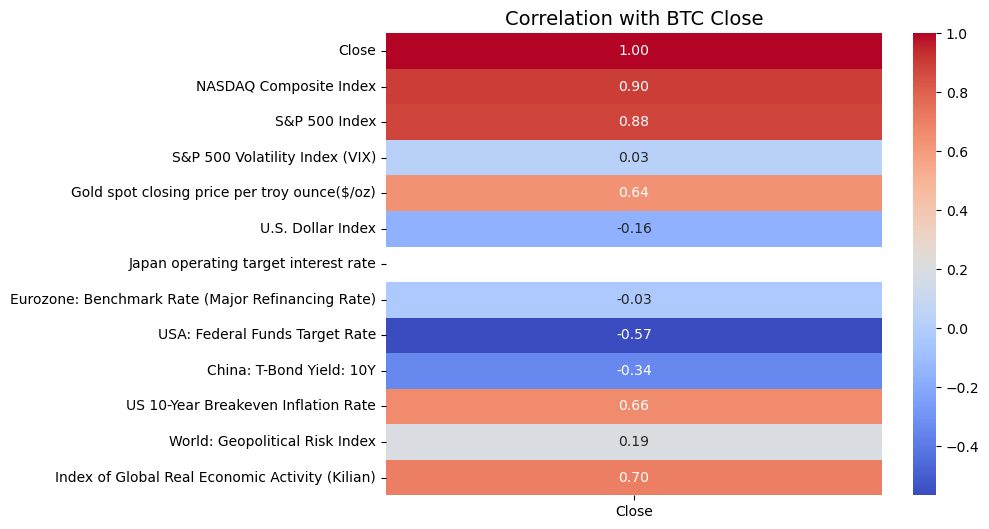

Correlation Coefficients and P-values with BTC Close:

NASDAQ Composite Index:
  Correlation = 0.9015, p-value = 0.0000e+00
S&P 500 Index:
  Correlation = 0.8832, p-value = 0.0000e+00
S&P 500 Volatility Index (VIX):
  Correlation = 0.0253, p-value = 2.7946e-01
Gold spot closing price per troy ounce($/oz):
  Correlation = 0.6382, p-value = 2.0042e-209
U.S. Dollar Index:
  Correlation = -0.1590, p-value = 8.4174e-12
Japan operating target interest rate:
  Correlation = nan, p-value = nan
Eurozone: Benchmark Rate (Major Refinancing Rate):
  Correlation = -0.0304, p-value = 1.9357e-01
USA: Federal Funds Target Rate:
  Correlation = -0.5654, p-value = 9.1782e-155
China: T-Bond Yield: 10Y:
  Correlation = -0.3448, p-value = 4.0781e-52
US 10-Year Breakeven Inflation Rate:
  Correlation = 0.6612, p-value = 6.5940e-230
World: Geopolitical Risk Index:
  Correlation = 0.1944, p-value = 5.2230e-17
Index of Global Real Economic Activity (Kilian):
  Correlation = 0.7042, p-value = 1.2883e-273


C:\Users\thinkpad\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# Read the data
df = pd.read_csv("Macro.csv")

# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Define correct column list
cols = ['Date', 'Close', 
        'NASDAQ Composite Index', 'S&P 500 Index', 'S&P 500 Volatility Index (VIX)', 
        'Gold spot closing price per troy ounce($/oz)', 'U.S. Dollar Index', 
        'Japan operating target interest rate', 'Eurozone: Benchmark Rate (Major Refinancing Rate)',
        'USA: Federal Funds Target Rate', 'China: T-Bond Yield: 10Y', 
        'US 10-Year Breakeven Inflation Rate', 'World: Geopolitical Risk Index',
        'Index of Global Real Economic Activity (Kilian)']

df = df[cols].dropna()
df['Date'] = pd.to_datetime(df['Date'])

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns=['Date']))
scaled_df = pd.DataFrame(scaled_data, columns=cols[1:])
scaled_df['Date'] = df['Date']

# Line plot comparison for each variable
for col in cols[2:]:
    plt.figure(figsize=(12, 5))
    plt.plot(scaled_df['Date'], scaled_df['Close'], label='BTC Close', color='black', linewidth=2)
    plt.plot(scaled_df['Date'], scaled_df[col], label=col, linestyle='--')
    plt.title(f'Comparison: BTC Close vs {col}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Standardized Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = scaled_df.drop(columns=['Date']).corr()
sns.heatmap(corr[['Close']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with BTC Close", fontsize=14)
plt.show()

# Print correlation coefficients and p-values
print("Correlation Coefficients and P-values with BTC Close:\n")
for col in cols[2:]:
    corr_coef, p_value = pearsonr(df['Close'], df[col])
    print(f"{col}:\n  Correlation = {corr_coef:.4f}, p-value = {p_value:.4e}")


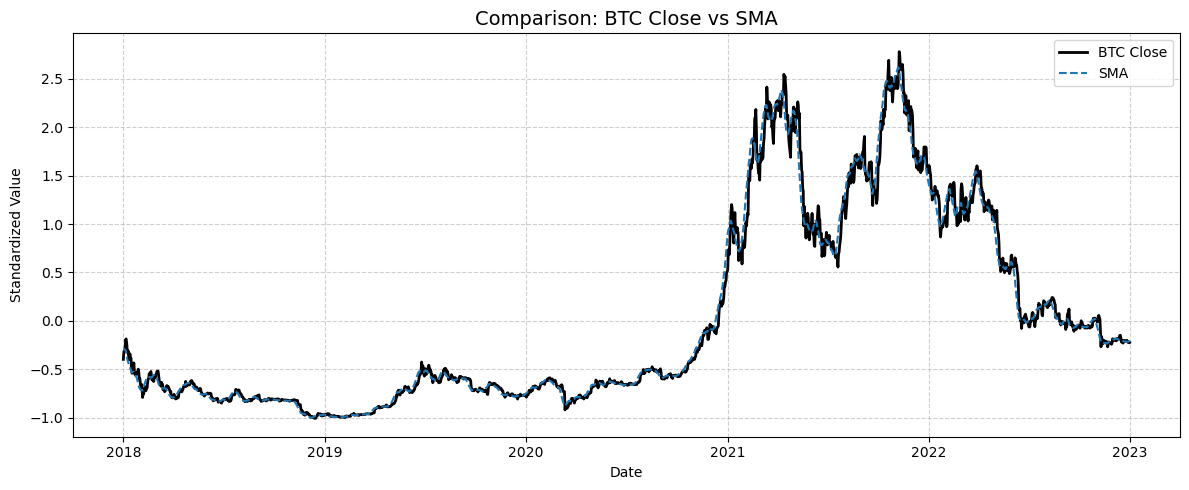

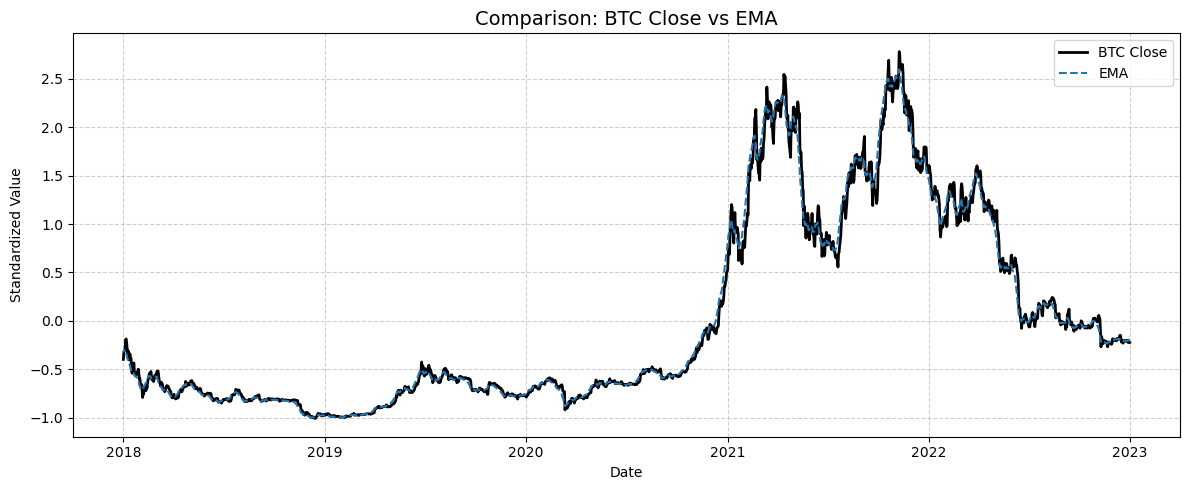

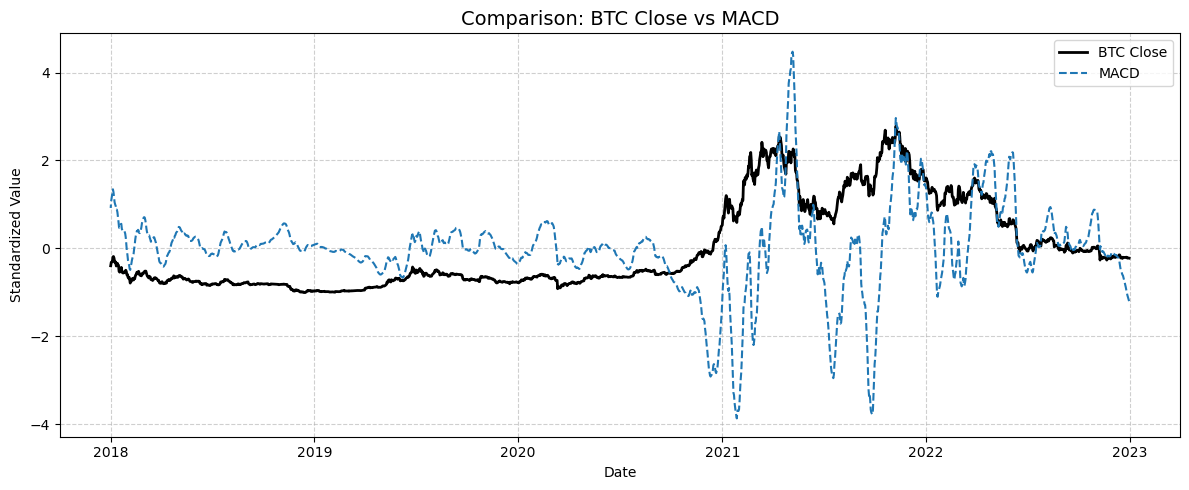

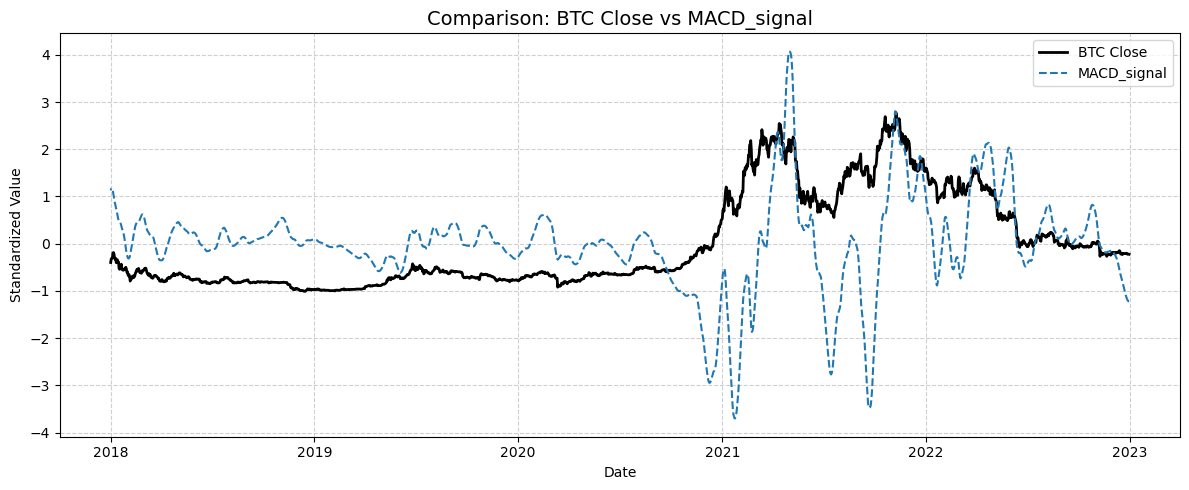

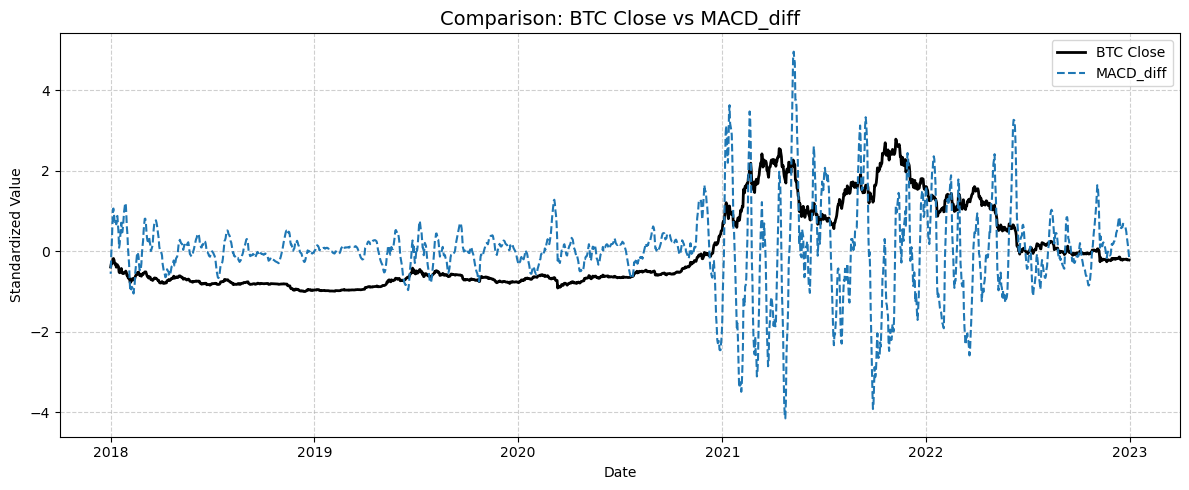

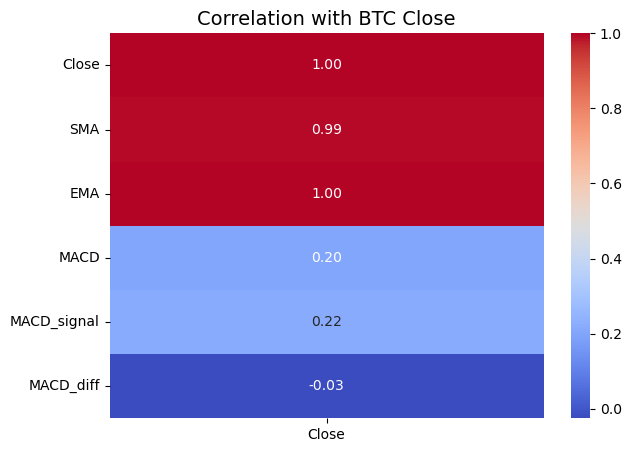

Correlation Coefficients and P-values with BTC Close:

SMA:
  Correlation = 0.9949, p-value = 0.0000e+00
EMA:
  Correlation = 0.9964, p-value = 0.0000e+00
MACD:
  Correlation = 0.1994, p-value = 7.8022e-18
MACD_signal:
  Correlation = 0.2169, p-value = 7.1204e-21
MACD_diff:
  Correlation = -0.0253, p-value = 2.8052e-01


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# Read the data
df = pd.read_csv("Technical.csv")

# Strip column name spaces and convert date
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

# Keep required columns
cols = ['Date', 'Close', 'SMA', 'EMA', 'MACD', 'MACD_signal', 'MACD_diff']
df = df[cols].dropna()

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns=['Date']))
scaled_df = pd.DataFrame(scaled_data, columns=cols[1:])
scaled_df['Date'] = df['Date']

# Line plot comparison for each variable
for col in cols[2:]:
    plt.figure(figsize=(12, 5))
    plt.plot(scaled_df['Date'], scaled_df['Close'], label='BTC Close', color='black', linewidth=2)
    plt.plot(scaled_df['Date'], scaled_df[col], label=col, linestyle='--')
    plt.title(f'Comparison: BTC Close vs {col}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Standardized Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = scaled_df.drop(columns='Date').corr()
sns.heatmap(corr[['Close']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with BTC Close", fontsize=14)
plt.show()

# Print correlation coefficients and p-values
print("Correlation Coefficients and P-values with BTC Close:\n")
for col in cols[2:]:
    corr_coef, p_value = pearsonr(df['Close'], df[col])
    print(f"{col}:\n  Correlation = {corr_coef:.4f}, p-value = {p_value:.4e}")


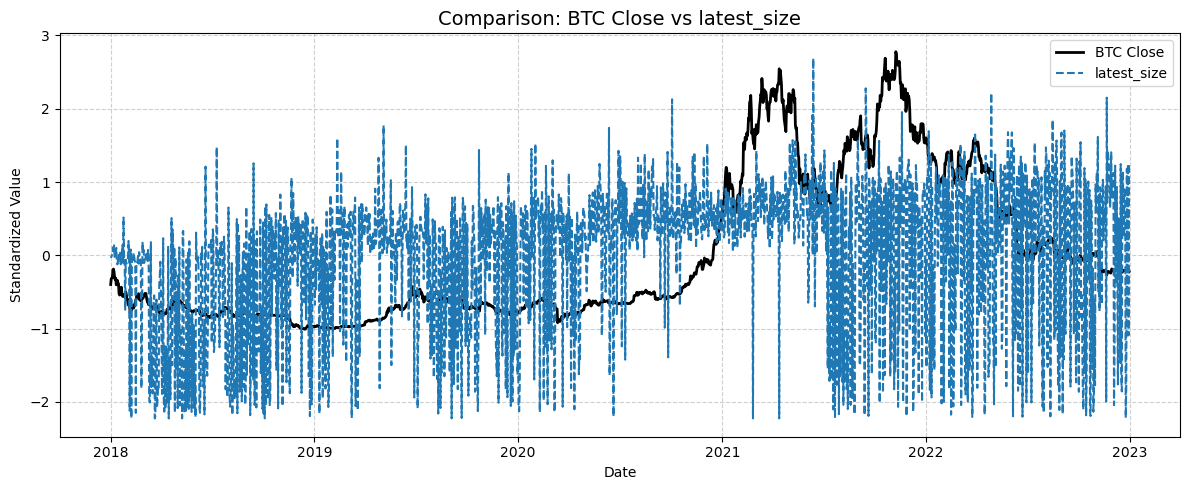

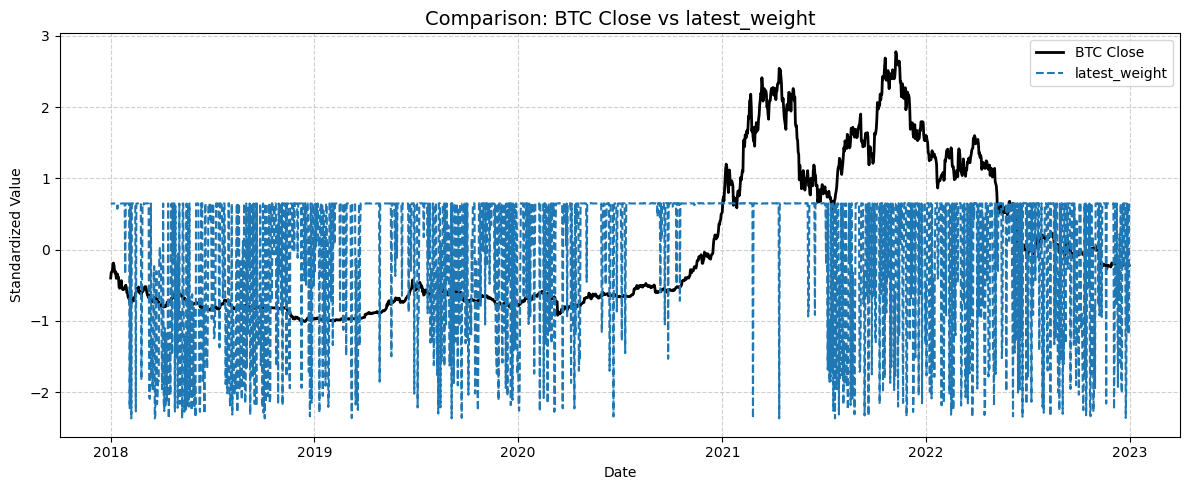

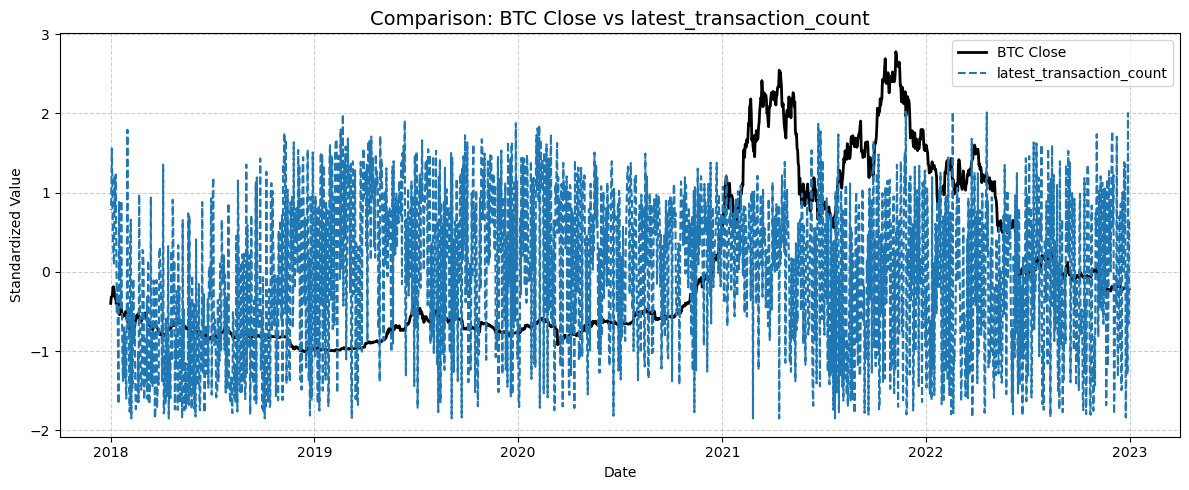

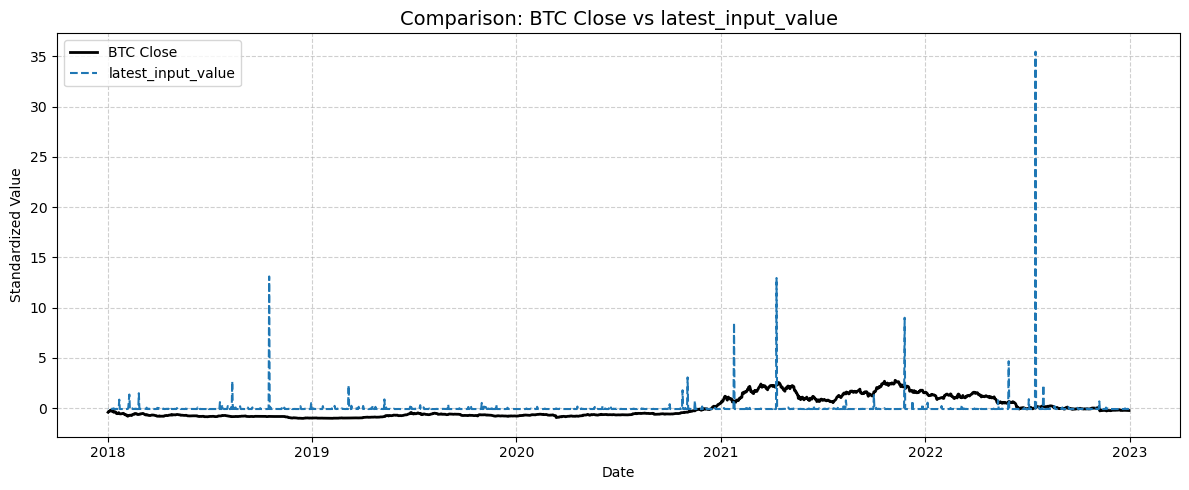

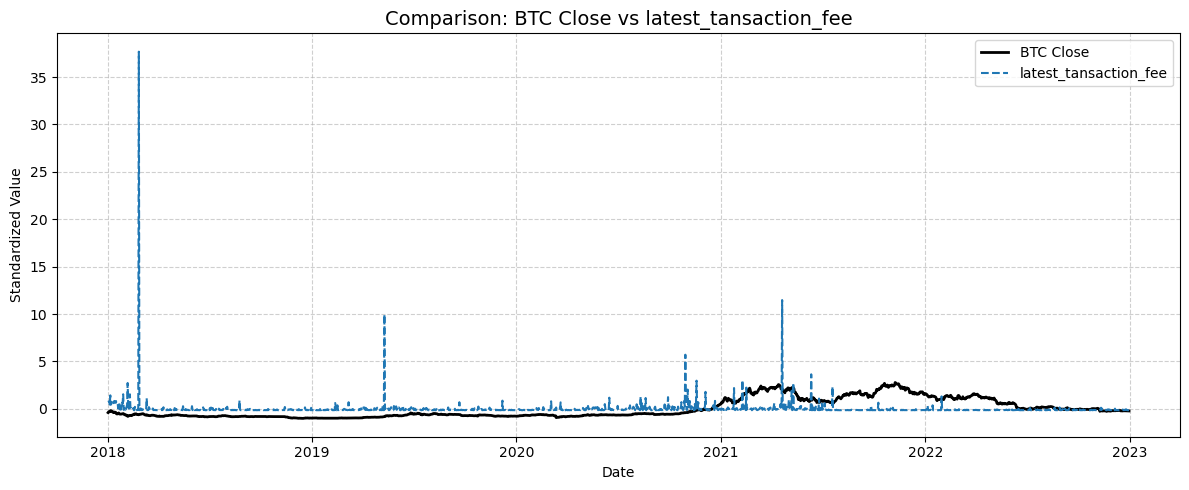

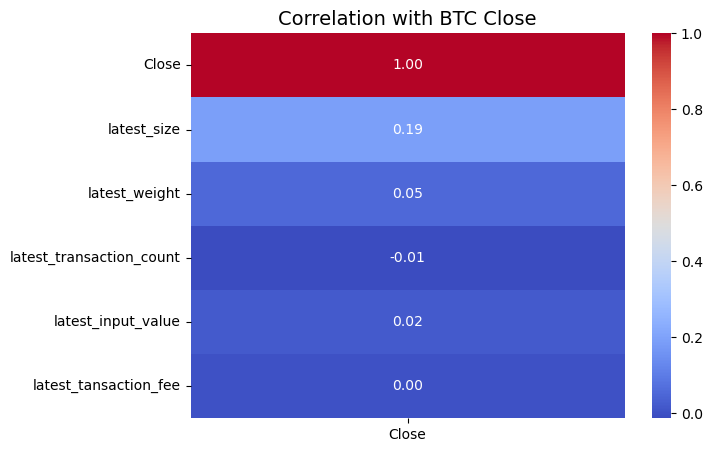

Correlation Coefficients and P-values with BTC Close:

latest_size:
  Correlation = 0.1889, p-value = 4.0105e-16
latest_weight:
  Correlation = 0.0503, p-value = 3.1456e-02
latest_transaction_count:
  Correlation = -0.0131, p-value = 5.7496e-01
latest_input_value:
  Correlation = 0.0224, p-value = 3.3794e-01
latest_tansaction_fee:
  Correlation = 0.0020, p-value = 9.3110e-01


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# Read the data
df = pd.read_csv("On-chain.csv")

# Strip whitespace from column names to ensure correct recognition
df.columns = df.columns.str.strip()

# Convert date format
df['Date'] = pd.to_datetime(df['Date'])

# Keep necessary columns and drop missing values
cols = ['Date', 'Close', 'latest_size', 'latest_weight', 
        'latest_transaction_count', 'latest_input_value', 'latest_tansaction_fee']
df = df[cols].dropna()

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns='Date'))
scaled_df = pd.DataFrame(scaled_data, columns=cols[1:])
scaled_df['Date'] = df['Date']

# Line plot to compare Close with each variable
for col in cols[2:]:
    plt.figure(figsize=(12, 5))
    plt.plot(scaled_df['Date'], scaled_df['Close'], label='BTC Close', color='black', linewidth=2)
    plt.plot(scaled_df['Date'], scaled_df[col], label=col, linestyle='--')
    plt.title(f'Comparison: BTC Close vs {col}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Standardized Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Heatmap showing correlations
plt.figure(figsize=(7, 5))
corr = scaled_df.drop(columns='Date').corr()
sns.heatmap(corr[['Close']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with BTC Close", fontsize=14)
plt.show()

# Output correlation coefficient and p-value for each variable against Close
print("Correlation Coefficients and P-values with BTC Close:\n")
for col in cols[2:]:
    corr_coef, p_value = pearsonr(df['Close'], df[col])
    print(f"{col}:\n  Correlation = {corr_coef:.4f}, p-value = {p_value:.4e}")


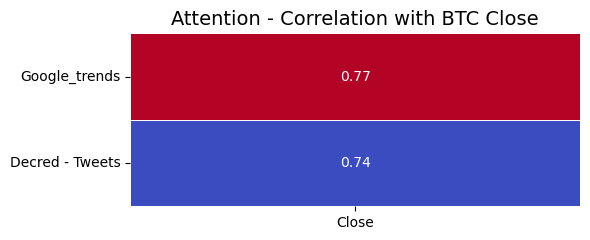

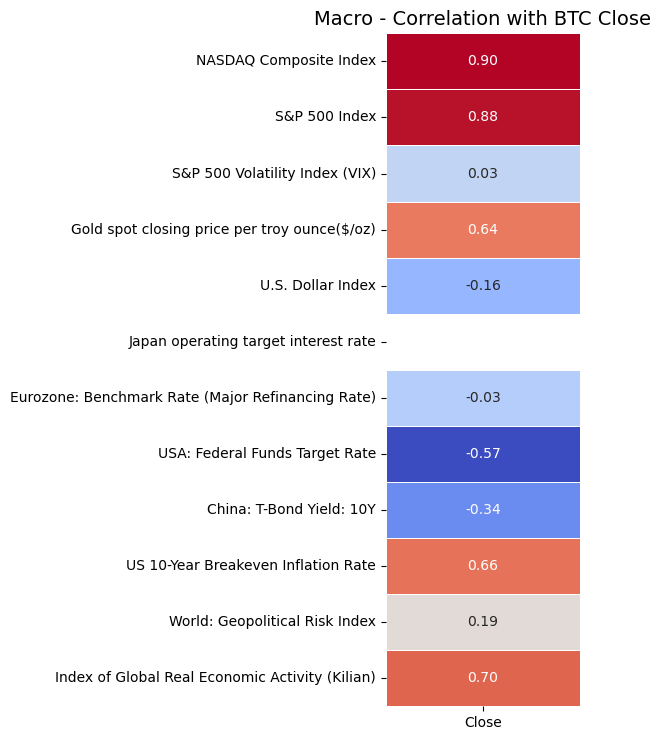

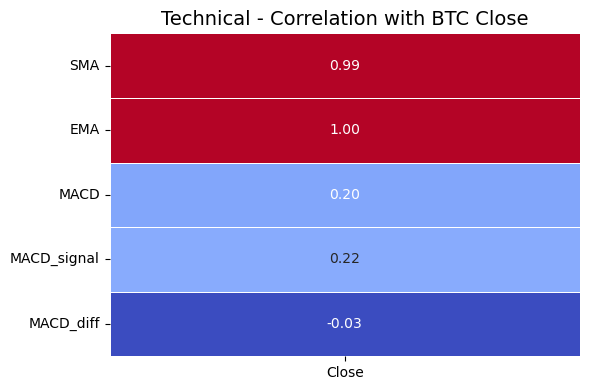

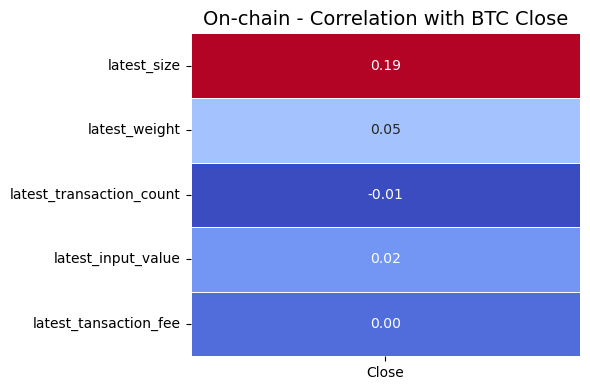

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# File paths
files = {
    "Attention": "Attention.csv",
    "Macro": "Macro.csv",
    "Technical": "Technical.csv",
    "On-chain": "On-chain.csv"
}

# Function to visualize correlation heatmap
def visualize_correlation_heatmap(file_path, dataset_name):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=['Close'])
    df = df.dropna(axis=0)

    # Keep only numeric columns (excluding Date)
    numeric_cols = df.select_dtypes(include=['number']).columns
    if 'Close' not in numeric_cols:
        return

    # Standardize numeric columns
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[numeric_cols])
    scaled_df = pd.DataFrame(scaled, columns=numeric_cols)

    # Plot correlation heatmap (only with Close)
    corr = scaled_df.corr()
    target_corr = corr[['Close']].drop('Close')
    
    plt.figure(figsize=(6, len(target_corr) * 0.5 + 1.5))
    sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=False)
    plt.title(f"{dataset_name} - Correlation with BTC Close", fontsize=14)
    plt.tight_layout()
    plt.show()

# Batch visualization
for name, path in files.items():
    visualize_correlation_heatmap(path, name)


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from IPython.display import display

# Custom variable: merged DataFrame from multiple datasets
df = pd.read_csv("Bitcoinall.csv")  
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()

# Keep Close and all other numeric columns (exclude strings)
cols_to_test = [col for col in df.columns if col != 'Date' and col != 'Close']

# Store results
results = []
for col in cols_to_test:
    try:
        corr, pval = pearsonr(df['Close'], df[col])
        results.append({
            'Predictor': col,
            'Correlation': round(corr, 4),
            'P-value': pval
        })
    except Exception as e:
        results.append({
            'Predictor': col,
            'Correlation': np.nan,
            'P-value': np.nan
        })

# Convert to DataFrame
df_corr = pd.DataFrame(results)

# Add absolute correlation column for sorting
df_corr['|Correlation|'] = df_corr['Correlation'].abs()

# Sort (first by p-value, then by absolute correlation)
df_corr = df_corr.sort_values(by=['P-value', '|Correlation|'], ascending=[True, False]).reset_index(drop=True)

# ✅ Add ranking (starting from 1)
df_corr['Rank'] = df_corr.index + 1

# Add recommendation column (whether to keep)
def flag_significance(row):
    if pd.isna(row['P-value']):
        return '❌ NaN'
    elif row['P-value'] > 0.05:
        return '❌ Not significant'
    elif row['|Correlation|'] >= 0.7:
        return '✅ Strong'
    elif row['|Correlation|'] >= 0.3:
        return '⚠️ Moderate'
    else:
        return '⚠️ Weak but significant'

df_corr['Suggestion'] = df_corr.apply(flag_significance, axis=1)

# Display final result
display(
    df_corr[['Rank', 'Predictor', 'Correlation', 'P-value', 'Suggestion']]
    .style.hide(axis="index")
)


C:\Users\thinkpad\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Rank,Predictor,Correlation,P-value,Suggestion
1,EMA,0.996400,0.000000,✅ Strong
2,SMA,0.994900,0.000000,✅ Strong
3,NASDAQ Composite Index,0.901500,0.000000,✅ Strong
4,S&P 500 Index,0.883200,0.000000,✅ Strong
5,Google_trends,0.767400,0.000000,✅ Strong
6,Decred - Tweets,0.744300,0.000000,✅ Strong
7,Index of Global Real Economic Activity (Kilian),0.704200,0.000000,✅ Strong
8,US 10-Year Breakeven Inflation Rate,0.661200,0.000000,⚠️ Moderate
9,Gold spot closing price per troy ounce($/oz),0.638200,0.000000,⚠️ Moderate
10,USA: Federal Funds Target Rate,-0.565400,0.000000,⚠️ Moderate


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from IPython.display import display

# Custom variable: merged DataFrame from multiple datasets
df = pd.read_csv("Bitcoinall.csv")  
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()

# Keep Close and all other numeric columns (exclude strings)
cols_to_test = [col for col in df.columns if col != 'Date' and col != 'Close']

# Store results
results = [{'Predictor': ' NASDAQ Composite Index',
  'Correlation': 0.90,
  'P-value': 0.0},
 {'Predictor': ' S&P 500 Index', 'Correlation': 0.88, 'P-value': 0.0},
 {'Predictor': 'S&P 500 Volatility Index (VIX)',
  'Correlation': 0.03,
  'P-value': 0.2794628280512948},
 {'Predictor': ' Gold spot closing price per troy ounce($/oz)',
  'Correlation': 0.64,
  'P-value': 2.0042451638229233e-209},
 {'Predictor': 'U.S. Dollar Index',
  'Correlation': -0.16,
  'P-value': 8.417361536468686e-12},
 {'Predictor': 'Eurozone: Benchmark Rate (Major Refinancing Rate)',
  'Correlation': -0.03,
  'P-value': 0.1935726446730327},
 {'Predictor': 'USA: Federal Funds Target Rate',
  'Correlation': -0.57,
  'P-value': 9.17819511727648e-155},
 {'Predictor': 'China: T-Bond Yield: 10Y',
  'Correlation': -0.34,
  'P-value': 4.07814076265188e-52},
 {'Predictor': 'US 10-Year Breakeven Inflation Rate',
  'Correlation': 0.66,
  'P-value': 6.593982223036975e-230},
 {'Predictor': 'World: Geopolitical Risk Index',
  'Correlation': 0.19,
  'P-value': 5.2230079651657037e-17},
 {'Predictor': 'Index of Global Real Economic Activity (Kilian)',
  'Correlation': 0.70,
  'P-value': 1.2882785274329812e-273},
 {'Predictor': 'latest_size',
  'Correlation': 0.19,
  'P-value': 4.010490633782894e-16},
 {'Predictor': 'latest_weight',
  'Correlation': 0.05,
  'P-value': 0.031456143774066116},
 {'Predictor': 'latest_transaction_count',
  'Correlation': -0.01,
  'P-value': 0.5749593969914825},
 {'Predictor': 'latest_input_value',
  'Correlation': 0.02,
  'P-value': 0.3379377049393518},
 {'Predictor': 'latest_tansaction_fee',
  'Correlation': 0.00,
  'P-value': 0.9310967046196076},
 {'Predictor': 'SMA', 'Correlation': 0.99, 'P-value': 0.0},
 {'Predictor': 'EMA', 'Correlation': 1.00, 'P-value': 0.0},
 {'Predictor': 'MACD', 'Correlation': 0.20, 'P-value': 7.80218534571192e-18},
 {'Predictor': 'MACD_signal',
  'Correlation': 0.22,
  'P-value': 7.120386059813833e-21},
 {'Predictor': 'MACD_diff',
  'Correlation': -0.03,
  'P-value': 0.280523986254652},
 {'Predictor': 'Google_trends', 'Correlation': 0.77, 'P-value': 0.0},
 {'Predictor': 'Decred - Tweets', 'Correlation': 0.744, 'P-value': 3.56e-322}]

# Convert to DataFrame
df_corr = pd.DataFrame(results)

# Add absolute correlation column for sorting
df_corr['|Correlation|'] = df_corr['Correlation'].abs()

# Sort (first by p-value, then by absolute correlation)
df_corr = df_corr.sort_values(by=['P-value', '|Correlation|'], ascending=[True, False]).reset_index(drop=True)

# ✅ Add ranking (starting from 1)
df_corr['Rank'] = df_corr.index + 1

# Add recommendation column (whether to retain the predictor)
def flag_significance(row):
    if pd.isna(row['P-value']):
        return '❌ NaN'
    elif row['P-value'] > 0.05:
        return '❌ Not significant'
    elif row['|Correlation|'] >= 0.7:
        return '✅ Strong'
    elif row['|Correlation|'] >= 0.3:
        return '⚠️ Moderate'
    else:
        return '⚠️ Weak but significant'

df_corr['Suggestion'] = df_corr.apply(flag_significance, axis=1)

# Display final result
display(
    df_corr[['Rank', 'Predictor', 'Correlation', 'P-value', 'Suggestion']]
    .style.hide_index()
)


C:\Users\thinkpad\AppData\Local\Temp\ipykernel_15628\1367678858.py:107: FutureWarning: this method is deprecated in favour of `Styler.hide(axis="index")`
  .style.hide_index()


Rank,Predictor,Correlation,P-value,Suggestion
1,EMA,1.000000,0.000000,✅ Strong
2,SMA,0.990000,0.000000,✅ Strong
3,NASDAQ Composite Index,0.900000,0.000000,✅ Strong
4,S&P 500 Index,0.880000,0.000000,✅ Strong
5,Google_trends,0.770000,0.000000,✅ Strong
6,Decred - Tweets,0.744000,0.000000,✅ Strong
7,Index of Global Real Economic Activity (Kilian),0.700000,0.000000,✅ Strong
8,US 10-Year Breakeven Inflation Rate,0.660000,0.000000,⚠️ Moderate
9,Gold spot closing price per troy ounce($/oz),0.640000,0.000000,⚠️ Moderate
10,USA: Federal Funds Target Rate,-0.570000,0.000000,⚠️ Moderate


In [2]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("Macro.csv")
df.columns = df.columns.str.strip()
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])


predictors = ['NASDAQ Composite Index', 'S&P 500 Index', 'S&P 500 Volatility Index (VIX)', 
              'Gold spot closing price per troy ounce($/oz)', 'U.S. Dollar Index', 
              'Japan operating target interest rate', 'Eurozone: Benchmark Rate (Major Refinancing Rate)',
              'USA: Federal Funds Target Rate', 'China: T-Bond Yield: 10Y', 
              'US 10-Year Breakeven Inflation Rate', 'World: Geopolitical Risk Index',
              'Index of Global Real Economic Activity (Kilian)']

X = df[predictors]


scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=predictors)

# VIF
vif_data = pd.DataFrame()
vif_data["Predictor"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]


vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif_data['Suggestion'] = vif_data['VIF'].apply(lambda v: 
    '✅ Acceptable' if v < 5 else ('⚠️ Moderate collinearity' if v < 10 else '❌ High collinearity'))

print(vif_data)


                                            Predictor        VIF  \
0                                       S&P 500 Index  81.607053   
1                              NASDAQ Composite Index  80.608532   
2                      USA: Federal Funds Target Rate  14.212922   
3                 US 10-Year Breakeven Inflation Rate   8.484468   
4                            China: T-Bond Yield: 10Y   8.345093   
5        Gold spot closing price per troy ounce($/oz)   8.335913   
6                                   U.S. Dollar Index   6.037542   
7   Eurozone: Benchmark Rate (Major Refinancing Rate)   5.084175   
8                      World: Geopolitical Risk Index   3.113199   
9                      S&P 500 Volatility Index (VIX)   3.084815   
10    Index of Global Real Economic Activity (Kilian)   2.780427   
11               Japan operating target interest rate        NaN   

                  Suggestion  
0        ❌ High collinearity  
1        ❌ High collinearity  
2        ❌ High collin

C:\Users\thinkpad\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

datasets = {
    "Technical": "Technical.csv",
    "Attention": "Attention.csv",
    "On-chain": "On-chain.csv"
}

for name, path in datasets.items():
    print(f"\n📊 VIF for {name} dataset")
    
    
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.dropna()
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.drop(columns=['Date'])
    if 'Close' in df.columns:
        df = df.drop(columns=['Close'])

    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

    # VIF
    vif_df = pd.DataFrame()
    vif_df["Predictor"] = X_scaled.columns
    vif_df["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
    vif_df["Suggestion"] = vif_df["VIF"].apply(lambda v: 
        '✅ Acceptable' if v < 5 else ('⚠️ Moderate collinearity' if v < 10 else '❌ High collinearity'))

  
    print(vif_df.sort_values(by='VIF', ascending=False).to_string(index=False))



📊 VIF for Technical dataset
  Predictor         VIF          Suggestion
       MACD         inf ❌ High collinearity
MACD_signal         inf ❌ High collinearity
  MACD_diff         inf ❌ High collinearity
        SMA 2901.375685 ❌ High collinearity
        EMA 2887.336570 ❌ High collinearity

📊 VIF for Attention dataset
      Predictor      VIF   Suggestion
  Google_trends 1.535066 ✅ Acceptable
Decred - Tweets 1.535066 ✅ Acceptable

📊 VIF for On-chain dataset
               Predictor      VIF               Suggestion
           latest_weight 9.215870 ⚠️ Moderate collinearity
             latest_size 8.038550 ⚠️ Moderate collinearity
latest_transaction_count 2.015333             ✅ Acceptable
      latest_input_value 1.003925             ✅ Acceptable
   latest_tansaction_fee 1.003762             ✅ Acceptable


C:\Users\thinkpad\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
